# Stock Price Forecasting Notebook

This notebook downloads historical price data, enriches it with Marketaux sentiment, trains LSTM and GRU models per symbol in a leakage-free pipeline, and compares them against a naive baseline.

In [1]:
%%capture
import sys
!{sys.executable} -m pip install --upgrade protobuf
%pip install yfinance tensorflow statsmodels vaderSentiment textblob requests

import warnings
warnings.filterwarnings("ignore")

import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import requests


## 1. Data Download

In [2]:
symbols = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]

data = {}
for sym in symbols:
    df_new = yf.download(sym, period="2y", interval="1d", auto_adjust=False, progress=False)
    df_new.index = pd.to_datetime(df_new.index).normalize()
    data[sym] = df_new.copy()
    print(sym, df_new.index.min(), "->", df_new.index.max(), df_new.shape)


AAPL 2024-04-18 00:00:00 -> 2026-04-17 00:00:00 (501, 6)
MSFT 2024-04-18 00:00:00 -> 2026-04-17 00:00:00 (501, 6)
GOOGL 2024-04-18 00:00:00 -> 2026-04-17 00:00:00 (501, 6)
AMZN 2024-04-18 00:00:00 -> 2026-04-17 00:00:00 (501, 6)
NVDA 2024-04-18 00:00:00 -> 2026-04-17 00:00:00 (501, 6)


In [3]:
for sym in symbols:
    df = data[sym].copy()
    df["returns"] = df["Close"].pct_change()
    data[sym] = df.dropna().copy()


## 2. Exploratory Data Analysis

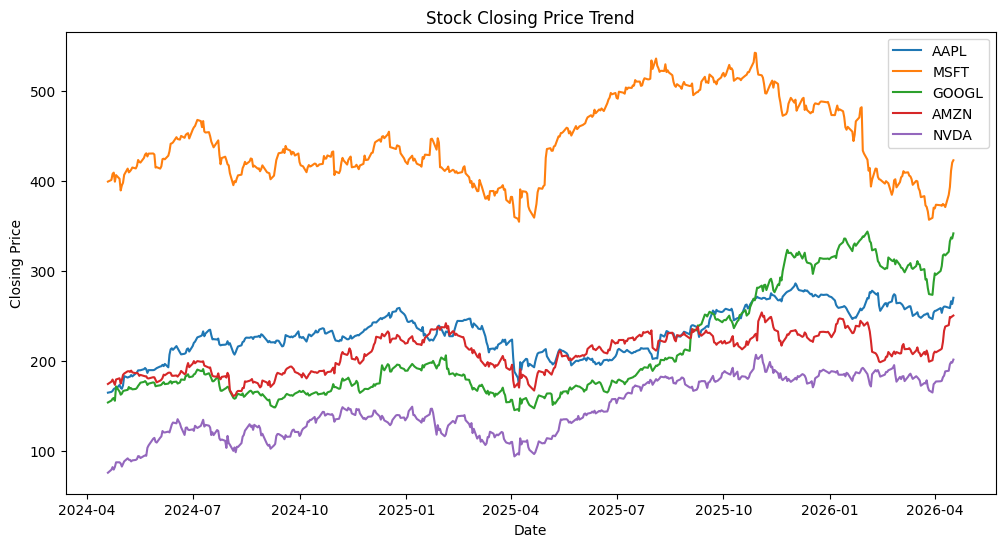

In [4]:
# Closing Price Trend
plt.figure(figsize=(12, 6))
for sym in symbols:
    plt.plot(data[sym].index, data[sym]["Close"], label=sym)
plt.title("Stock Closing Price Trend")
plt.xlabel("Date"); plt.ylabel("Closing Price"); plt.legend(); plt.show()


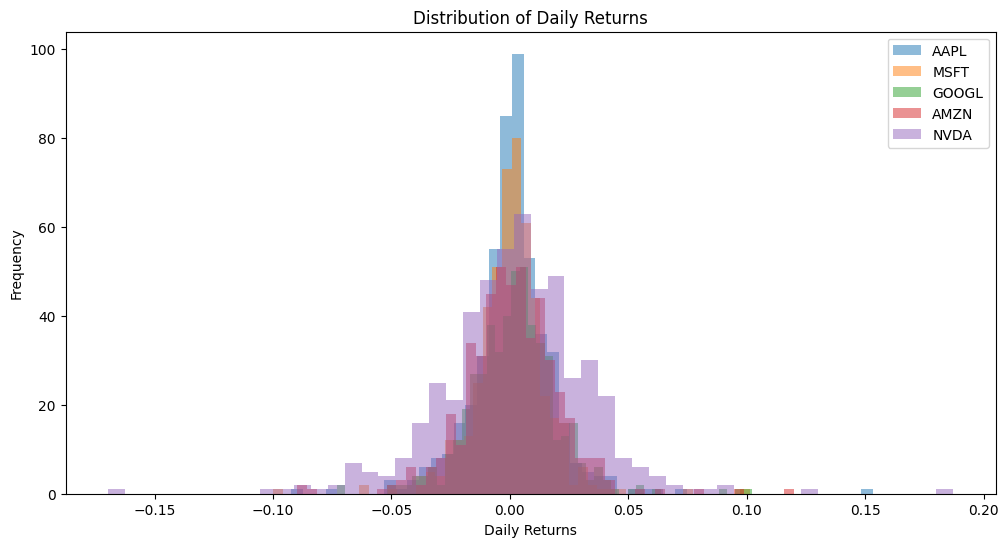

In [5]:
# Daily Returns Distribution
plt.figure(figsize=(12, 6))
for sym in symbols:
    plt.hist(data[sym]["returns"].dropna(), bins=50, alpha=0.5, label=sym)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Returns"); plt.ylabel("Frequency"); plt.legend(); plt.show()


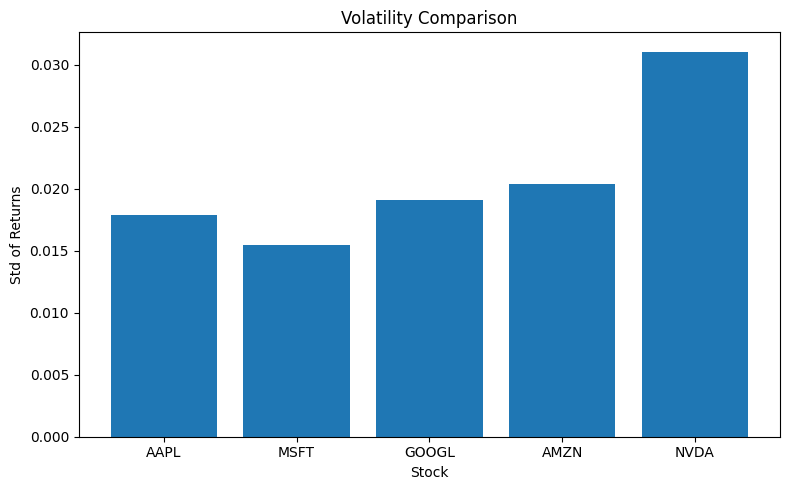

In [6]:
# Volatility Comparison
vol_df = pd.DataFrame({
    "Stock": symbols,
    "Volatility": [data[sym]["returns"].std() for sym in symbols]
})
plt.figure(figsize=(8, 5))
plt.bar(vol_df["Stock"].values, vol_df["Volatility"].values)
plt.title("Volatility Comparison"); plt.xlabel("Stock"); plt.ylabel("Std of Returns")
plt.tight_layout(); plt.show()


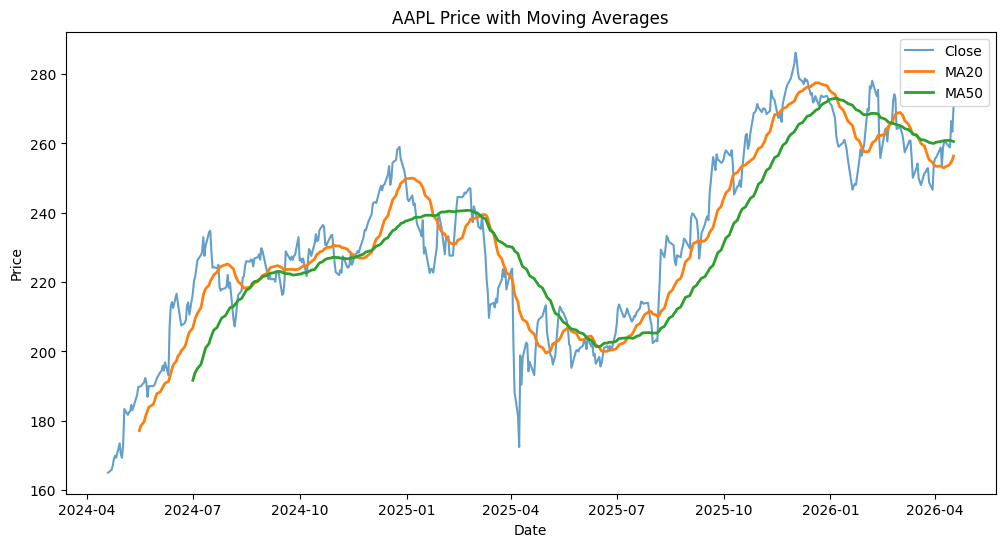

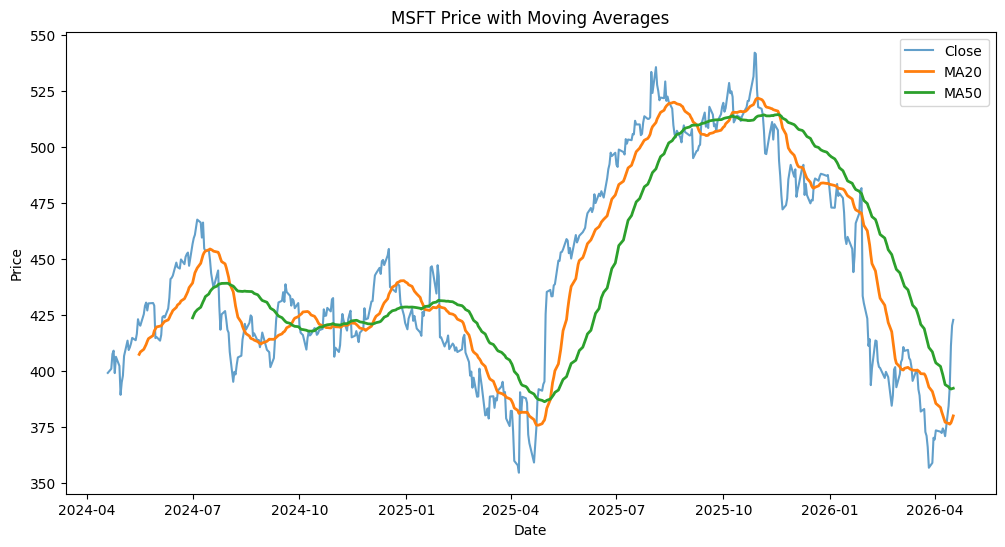

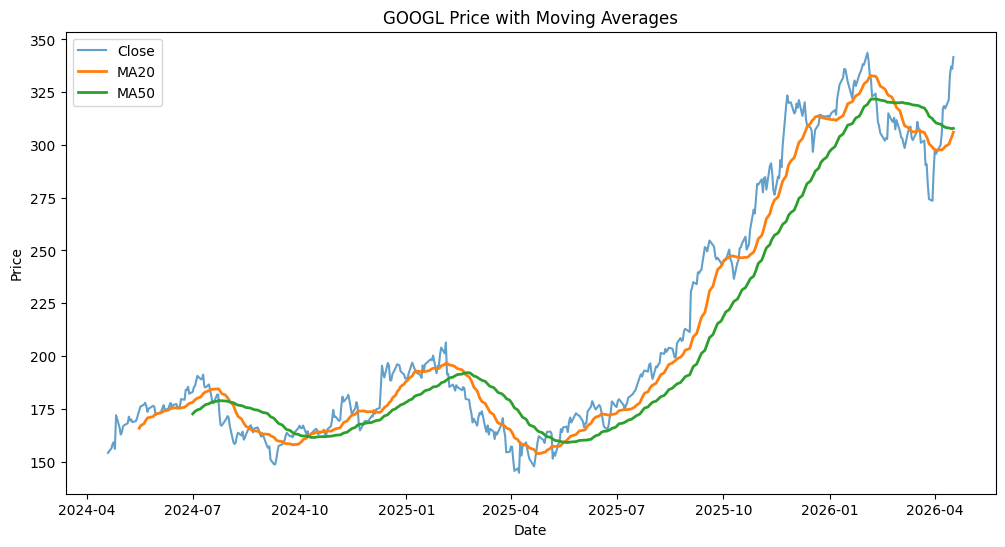

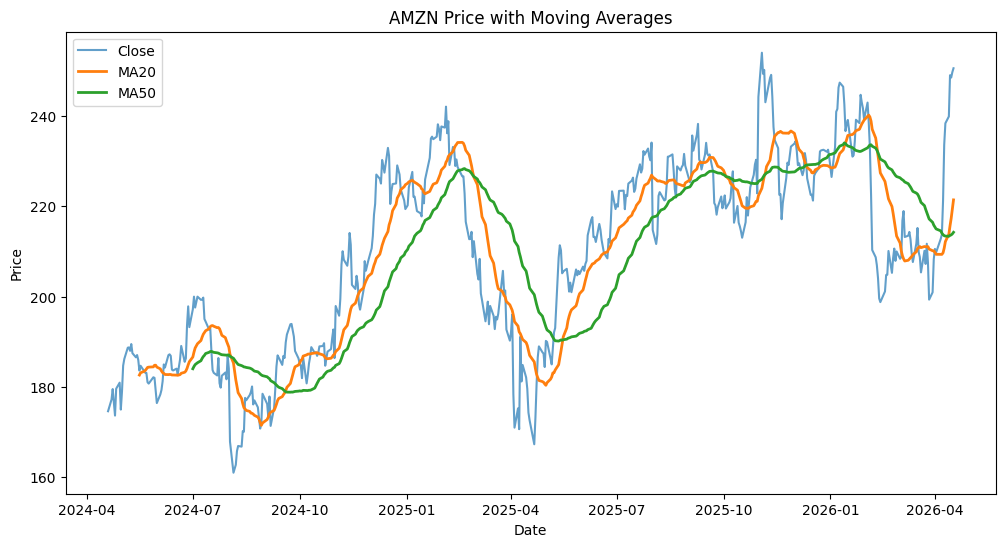

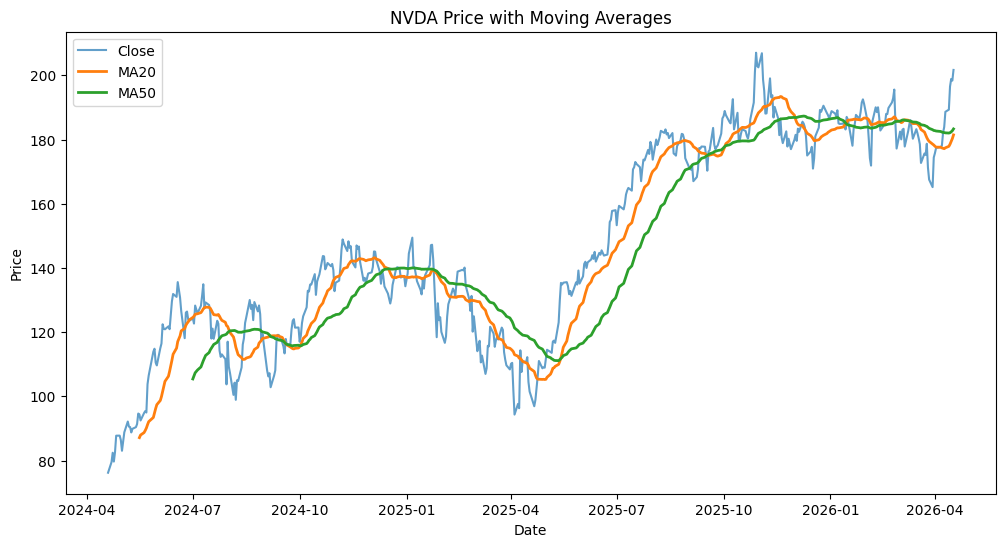

In [7]:
# Moving Averages
for sym in symbols:
    df = data[sym].copy()
    df["MA20"] = df["Close"].rolling(20).mean()
    df["MA50"] = df["Close"].rolling(50).mean()
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df["Close"], label="Close", alpha=0.7)
    plt.plot(df.index, df["MA20"], label="MA20", linewidth=2)
    plt.plot(df.index, df["MA50"], label="MA50", linewidth=2)
    plt.title(f"{sym} Price with Moving Averages")
    plt.xlabel("Date"); plt.ylabel("Price"); plt.legend(); plt.show()


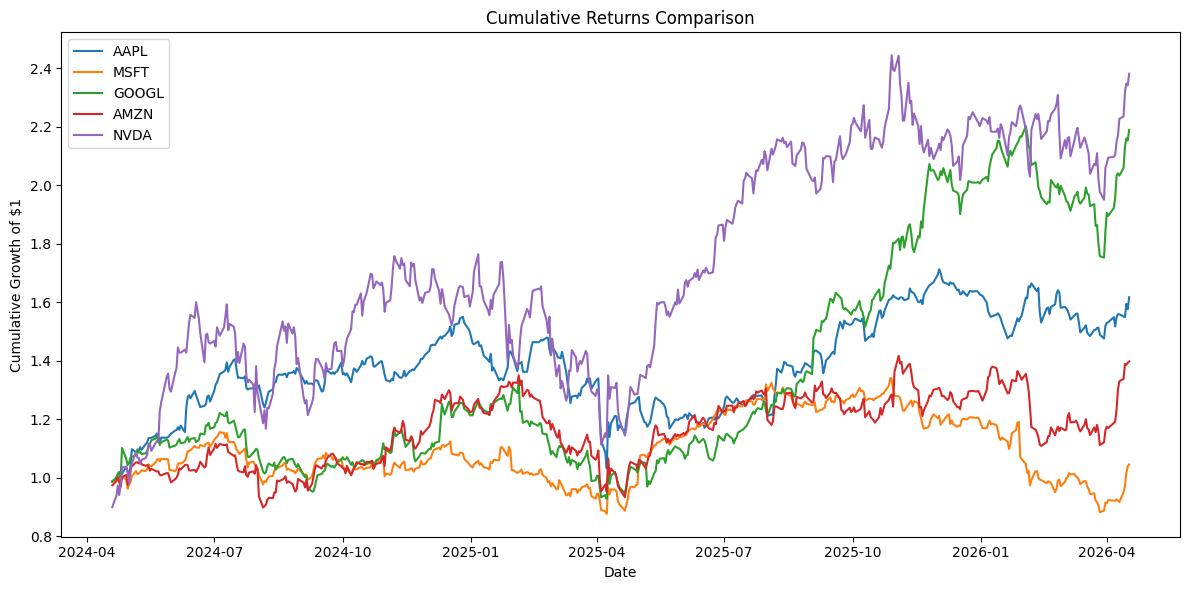

In [8]:
# Cumulative Returns
plt.figure(figsize=(12, 6))
for sym in symbols:
    cum = (1 + data[sym]["returns"]).cumprod()
    plt.plot(cum, label=sym)
plt.title("Cumulative Returns Comparison")
plt.xlabel("Date"); plt.ylabel("Cumulative Growth of $1"); plt.legend()
plt.tight_layout(); plt.show()


## 3. ARIMA Baseline

In [9]:
arima_orders = [(1,1,0),(2,1,0),(3,1,0),(5,1,0),(2,1,2)]

warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

def evaluate_predictions(actual, pred):
    actual = np.asarray(actual).reshape(-1)
    pred   = np.asarray(pred).reshape(-1)
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    return mae, rmse

for sym in symbols:
    print(f"\n===== {sym} ARIMA =====")
    df = data[sym].copy()
    df.index = pd.DatetimeIndex(df.index)
    df = df.asfreq("B")
    prices = df["Close"].dropna()

    train_end = int(len(prices) * 0.70)
    val_end   = int(len(prices) * 0.85)

    train = prices.iloc[:train_end]
    val   = prices.iloc[train_end:val_end]
    test  = prices.iloc[val_end:]

    best_order, best_val_rmse = None, float("inf")
    for order in arima_orders:
        try:
            fitted = ARIMA(train, order=order).fit()
            _, val_rmse = evaluate_predictions(val.values, fitted.forecast(steps=len(val)).values)
            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_order = order
        except Exception:
            continue

    print(f"Best order: ARIMA{best_order}, Val RMSE: {best_val_rmse:.3f}")
    final_fitted = ARIMA(prices.iloc[:val_end], order=best_order).fit()
    test_mae, test_rmse = evaluate_predictions(test.values, final_fitted.forecast(steps=len(test)).values)
    print(f"Test MAE: {test_mae:.3f}, Test RMSE: {test_rmse:.3f}")



===== AAPL ARIMA =====
Best order: ARIMA(5, 1, 0), Val RMSE: 35.437
Test MAE: 13.384, Test RMSE: 15.337

===== MSFT ARIMA =====
Best order: ARIMA(2, 1, 2), Val RMSE: 17.545
Test MAE: 72.399, Test RMSE: 81.395

===== GOOGL ARIMA =====
Best order: ARIMA(2, 1, 2), Val RMSE: 47.359
Test MAE: 13.109, Test RMSE: 16.029

===== AMZN ARIMA =====
Best order: ARIMA(1, 1, 0), Val RMSE: 9.270
Test MAE: 16.495, Test RMSE: 18.778

===== NVDA ARIMA =====
Best order: ARIMA(2, 1, 0), Val RMSE: 10.230
Test MAE: 6.183, Test RMSE: 8.075


## 4. Marketaux Sentiment Pipeline

In [10]:
MARKETAUX_API_KEY = "Pha16vU7MSEZmN3BAdLaPsp3GnX5vjW2FzmkgELE"

def fetch_marketaux_news(symbol, start_date, end_date, limit=100):
    url = "https://api.marketaux.com/v1/news/all"
    params = {
        "api_token": MARKETAUX_API_KEY,
        "symbols": symbol,
        "language": "en",
        "must_have_entities": "true",
        "published_after":  pd.Timestamp(start_date).strftime("%Y-%m-%dT00:00:00"),
        "published_before": pd.Timestamp(end_date).strftime("%Y-%m-%dT23:59:59"),
        "limit": limit
    }
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    payload = response.json()
    rows = []
    for article in payload.get("data", []):
        pub_date = article.get("published_at")
        title    = article.get("title", "")
        entities = article.get("entities", [])
        if pub_date is None:
            continue
        dt = pd.to_datetime(pub_date, utc=True, errors="coerce")
        if pd.isna(dt):
            continue
        dt = dt.tz_localize(None).normalize()
        scores = [float(e["sentiment_score"]) for e in entities
                  if e.get("symbol") == symbol and e.get("sentiment_score") is not None]
        if scores:
            rows.append({"news_date": dt, "title": title, "sentiment_raw": float(np.mean(scores))})
    if not rows:
        return pd.DataFrame(columns=["news_date", "title", "sentiment_raw"])
    return pd.DataFrame(rows).sort_values("news_date")


In [11]:
def flatten_columns(df):
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = ["_".join([str(x) for x in col if str(x) != ""]).strip("_")
                      for col in df.columns.to_flat_index()]
    return df

def build_marketaux_dataset(data, symbols, limit=100):
    marketaux_data = {}
    validation_rows = []

    for sym in symbols:
        print(f"\n=== {sym} ===")
        df = flatten_columns(data[sym].copy())
        df.index = pd.to_datetime(df.index).normalize()
        df = df.sort_index()

        news_df = fetch_marketaux_news(sym, df.index.min(), df.index.max(), limit=limit)

        trade_df = df.reset_index()
        trade_df.columns = [str(c) for c in trade_df.columns]
        trade_df = trade_df.rename(columns={trade_df.columns[0]: "trade_date"})
        trade_df["trade_date"] = pd.to_datetime(trade_df["trade_date"]).dt.normalize()
        trade_df = trade_df.sort_values("trade_date")

        if news_df.empty:
            trade_df["sentiment_raw"] = 0.0
            trade_df["news_count"]    = 0
            print("No news found; filled sentiment with 0.")
        else:
            daily_news = (news_df.groupby("news_date")
                          .agg(sentiment_raw=("sentiment_raw","mean"), news_count=("sentiment_raw","size"))
                          .reset_index().sort_values("news_date"))
            aligned = pd.merge_asof(trade_df.sort_values("trade_date"), daily_news.sort_values("news_date"),
                                    left_on="trade_date", right_on="news_date", direction="backward")
            trade_df["sentiment_raw"] = aligned["sentiment_raw"].fillna(0.0)
            trade_df["news_count"]    = aligned["news_count"].fillna(0).astype(int)
            print(f"News rows: {len(news_df)}, days with sentiment: {int((trade_df['sentiment_raw']!=0).sum())}")

        trade_df = trade_df.set_index("trade_date").sort_index()
        close_col = "Close" if "Close" in trade_df.columns else [c for c in trade_df.columns if "Close" in c][0]
        trade_df["returns"]        = trade_df[close_col].pct_change()
        trade_df["sentiment_lag1"] = trade_df["sentiment_raw"].shift(1).fillna(0.0)
        trade_df["sentiment_ma_3"] = trade_df["sentiment_lag1"].rolling(3, min_periods=1).mean()
        trade_df["sentiment_ma_5"] = trade_df["sentiment_lag1"].rolling(5, min_periods=1).mean()
        if close_col != "Close":
            trade_df["Close"] = trade_df[close_col]

        marketaux_data[sym] = trade_df
        validation_rows.append({
            "label": sym,
            "n_news_items":    int(len(news_df)),
            "n_sentiment_days": int((trade_df["sentiment_raw"]!=0).sum()),
            "mean_sentiment":  float(trade_df["sentiment_raw"].replace(0,np.nan).mean()) if (trade_df["sentiment_raw"]!=0).any() else np.nan,
            "std_sentiment":   float(trade_df["sentiment_raw"].replace(0,np.nan).std())  if (trade_df["sentiment_raw"]!=0).any() else np.nan,
        })

    return marketaux_data, pd.DataFrame(validation_rows)

marketaux_data, marketaux_validation_summary = build_marketaux_dataset(data, symbols, limit=100)
print("\nMarketaux Validation Summary")
display(marketaux_validation_summary)



=== AAPL ===
News rows: 3, days with sentiment: 1

=== MSFT ===
News rows: 3, days with sentiment: 1

=== GOOGL ===
News rows: 3, days with sentiment: 1

=== AMZN ===
News rows: 3, days with sentiment: 1

=== NVDA ===
News rows: 3, days with sentiment: 1

Marketaux Validation Summary


,label,n_news_items,n_sentiment_days,mean_sentiment,std_sentiment
0,AAPL,3,1,0.524700,NaN
1,MSFT,3,1,0.309380,NaN
2,GOOGL,3,1,0.398017,NaN
3,AMZN,3,1,0.358100,NaN
4,NVDA,3,1,0.296789,NaN


## 5. Shared Model Helpers

In [12]:
window_size = 60

def create_sequences(feature_array, target_array, window_size=60):
    X, y = [], []
    feature_array = np.asarray(feature_array)
    target_array  = np.asarray(target_array)
    for i in range(window_size, len(feature_array)):
        X.append(feature_array[i-window_size:i])
        y.append(target_array[i])
    return np.array(X), np.array(y)

def prepare_symbol_data_leakage_free(df, feature_cols, target_col="Close", window_size=60):
    df = df.copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()
    needed_cols = list(dict.fromkeys(feature_cols + [target_col]))
    df_model = df[needed_cols].dropna().copy()

    n         = len(df_model)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.85)

    train_df = df_model.iloc[:train_end]
    val_df   = df_model.iloc[train_end:val_end]
    test_df  = df_model.iloc[val_end:]

    feature_scaler = MinMaxScaler()
    target_scaler  = MinMaxScaler()

    train_features = feature_scaler.fit_transform(train_df[feature_cols])
    val_features   = feature_scaler.transform(val_df[feature_cols])
    test_features  = feature_scaler.transform(test_df[feature_cols])

    train_target = target_scaler.fit_transform(train_df[target_col].to_numpy().reshape(-1,1))
    val_target   = target_scaler.transform(val_df[target_col].to_numpy().reshape(-1,1))
    test_target  = target_scaler.transform(test_df[target_col].to_numpy().reshape(-1,1))

    X_train, y_train = create_sequences(train_features, train_target, window_size)

    val_feat_ctx   = np.vstack([train_features[-window_size:],  val_features])
    val_tgt_ctx    = np.vstack([train_target[-window_size:],    val_target])
    X_val, y_val   = create_sequences(val_feat_ctx, val_tgt_ctx, window_size)

    test_feat_ctx  = np.vstack([val_features[-window_size:],    test_features])
    test_tgt_ctx   = np.vstack([val_target[-window_size:],      test_target])
    X_test, y_test = create_sequences(test_feat_ctx, test_tgt_ctx, window_size)

    return dict(df_model=df_model, train_df=train_df, val_df=val_df, test_df=test_df,
                feature_scaler=feature_scaler, target_scaler=target_scaler,
                X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
                X_test=X_test,  y_test=y_test)

def directional_accuracy_from_prices(actual, predicted, prev):
    actual    = np.asarray(actual).reshape(-1)
    predicted = np.asarray(predicted).reshape(-1)
    prev      = np.asarray(prev).reshape(-1)
    m = min(len(actual), len(predicted), len(prev))
    actual, predicted, prev = actual[:m], predicted[:m], prev[:m]
    return float(((actual > prev).astype(int) == (predicted > prev).astype(int)).mean())


## 6. LSTM & GRU Training (per symbol)

In [29]:
def train_lstm_gru_for_symbol(sym, marketaux_data, window_size=60):
    pack = prepare_symbol_data_leakage_free(
        df=marketaux_data[sym].copy(),
        feature_cols=["Close", "returns", "sentiment_ma_5"],
        target_col="returns",
        window_size=window_size
    )

    X_train, y_train   = pack["X_train"], pack["y_train"]
    X_val,   y_val     = pack["X_val"],   pack["y_val"]
    X_test,  y_test    = pack["X_test"],  pack["y_test"]
    target_scaler      = pack["target_scaler"]
    timesteps          = X_train.shape[1]
    n_features         = X_train.shape[2]

    early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

    # ── LSTM ──
    lstm_model = Sequential([
        Input(shape=(timesteps, n_features)),
        LSTM(50),
        Dropout(0.3),
        Dense(1)
    ])
    lstm_model.compile(optimizer="adam", loss="mse")
    lstm_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                   epochs=50, batch_size=32, callbacks=[early_stop], verbose=0)

    # ── GRU ──
    gru_model = Sequential([
        Input(shape=(timesteps, n_features)),
        GRU(50),
        Dropout(0.3),
        Dense(1)
    ])
    gru_model.compile(optimizer="adam", loss="mse")
    gru_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                  epochs=50, batch_size=32, callbacks=[early_stop], verbose=0)

    # ── Evaluate ──
    def eval_model(model):
        pred_scaled = model.predict(X_test, verbose=0)
        pred   = target_scaler.inverse_transform(pred_scaled).reshape(-1)
        y_true = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)
        mae    = mean_absolute_error(y_true, pred)
        rmse   = np.sqrt(np.mean((y_true - pred) ** 2))
        return mae, rmse, y_true, pred

    lstm_mae, lstm_rmse, y_true, lstm_pred = eval_model(lstm_model)
    gru_mae,  gru_rmse,  _,      gru_pred  = eval_model(gru_model)

    # ── Directional accuracy (sign of return = direction) ──
    actual_dir = (y_true    > 0).astype(int)
    lstm_da    = float((actual_dir == (lstm_pred > 0).astype(int)).mean())
    gru_da     = float((actual_dir == (gru_pred  > 0).astype(int)).mean())

    return {
        "lstm_model":  lstm_model,
        "gru_model":   gru_model,
        "y_true":      y_true,
        "lstm_pred":   lstm_pred,
        "gru_pred":    gru_pred,
        "lstm_result": {
            "symbol": sym, "model": "LSTM + Marketaux",
            "features": "Close, returns, sentiment_ma_5",
            "mae": lstm_mae, "rmse": lstm_rmse, "directional_accuracy": lstm_da
        },
        "gru_result": {
            "symbol": sym, "model": "GRU + Marketaux",
            "features": "Close, returns, sentiment_ma_5",
            "mae": gru_mae, "rmse": gru_rmse, "directional_accuracy": gru_da
        },
    }

In [30]:
model_results = []
trained_models = {}
plot_data = {}

for sym in symbols:
    print(f"\nTraining {sym}...")
    try:
        out = train_lstm_gru_for_symbol(sym, marketaux_data, window_size=window_size)
        trained_models[f"{sym}_lstm"] = out["lstm_model"]
        trained_models[f"{sym}_gru"]  = out["gru_model"]
        model_results.append(out["lstm_result"])
        model_results.append(out["gru_result"])
        plot_data[sym] = out
        print(f"  LSTM -> MAE={out['lstm_result']['mae']:.3f}, RMSE={out['lstm_result']['rmse']:.3f}, DA={out['lstm_result']['directional_accuracy']:.3f}")
        print(f"  GRU  -> MAE={out['gru_result']['mae']:.3f},  RMSE={out['gru_result']['rmse']:.3f},  DA={out['gru_result']['directional_accuracy']:.3f}")
    except Exception as e:
        print(f"  {sym} failed: {e}")



Training AAPL...
  LSTM -> MAE=0.011, RMSE=0.015, DA=0.480
  GRU  -> MAE=0.071,  RMSE=0.072,  DA=0.520

Training MSFT...
  LSTM -> MAE=0.014, RMSE=0.021, DA=0.547
  GRU  -> MAE=0.020,  RMSE=0.026,  DA=0.547

Training GOOGL...
  LSTM -> MAE=0.013, RMSE=0.017, DA=0.520
  GRU  -> MAE=0.024,  RMSE=0.027,  DA=0.493

Training AMZN...
  LSTM -> MAE=0.016, RMSE=0.020, DA=0.547
  GRU  -> MAE=0.033,  RMSE=0.040,  DA=0.547

Training NVDA...
  LSTM -> MAE=0.017, RMSE=0.022, DA=0.507
  GRU  -> MAE=0.026,  RMSE=0.031,  DA=0.453


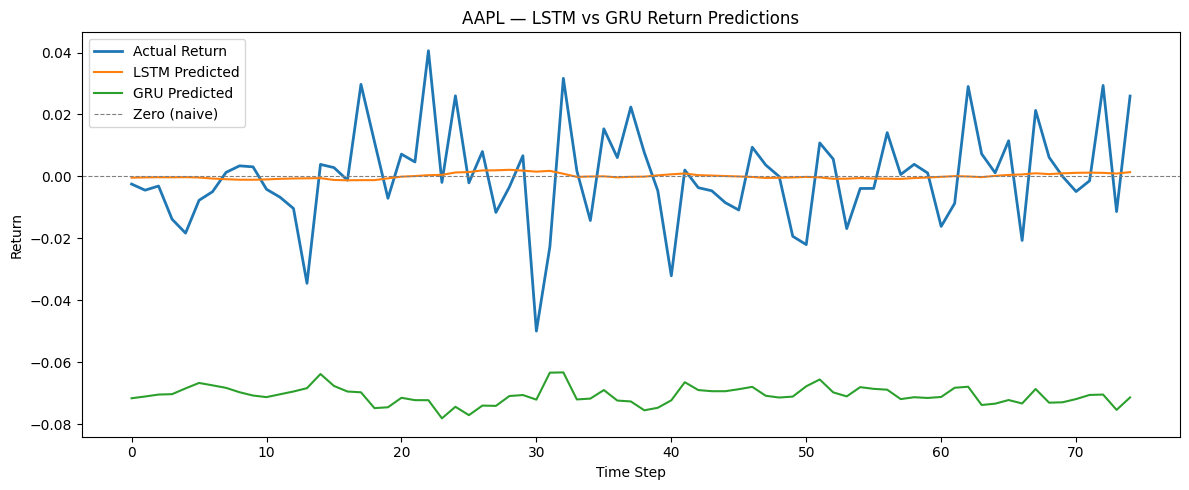

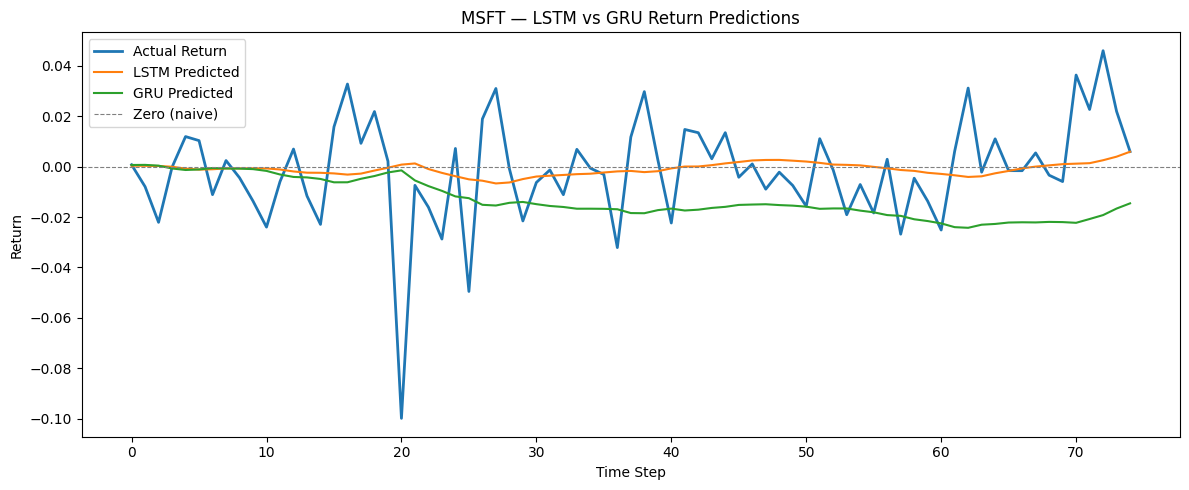

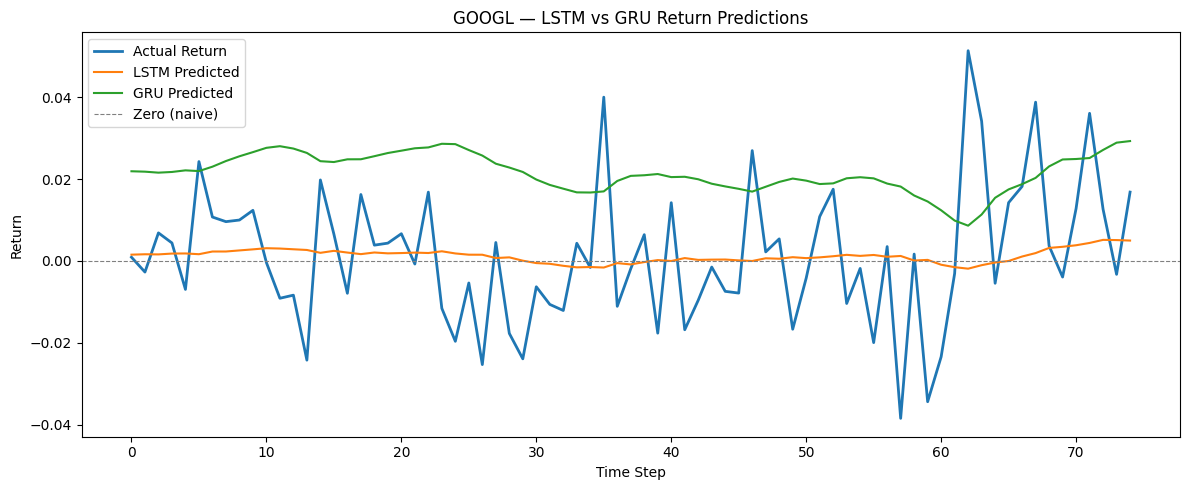

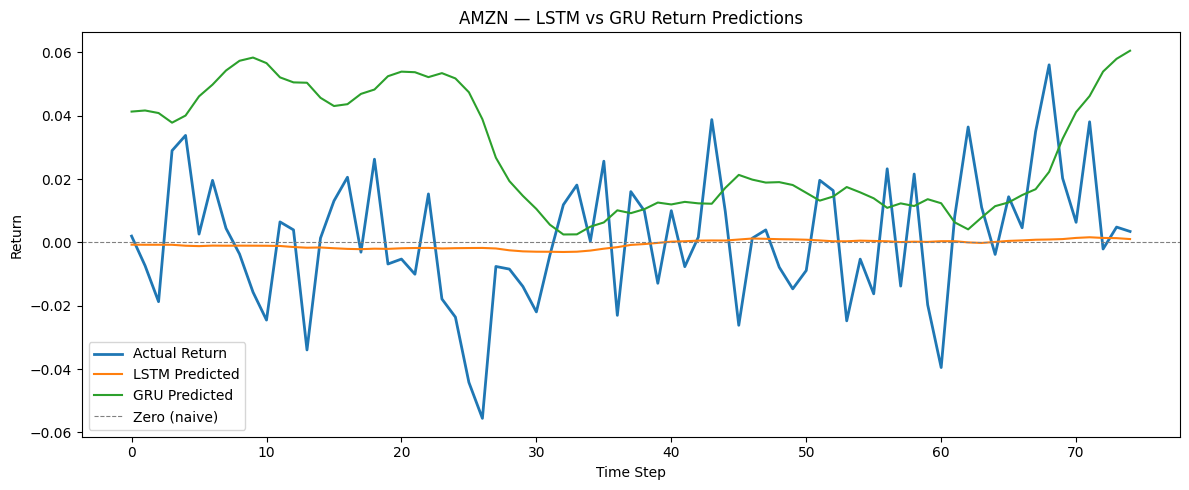

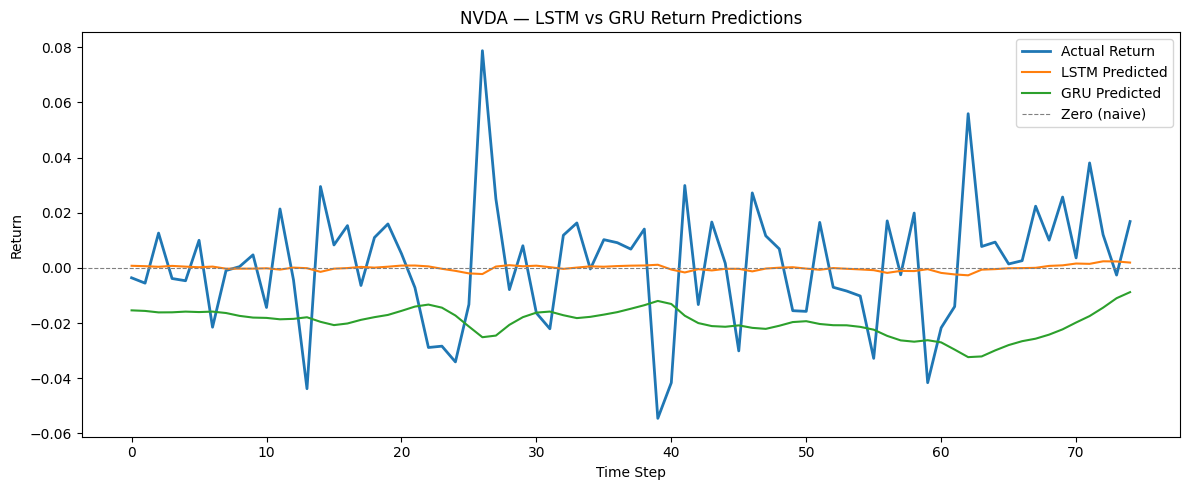

In [32]:
for sym, out in plot_data.items():
    plt.figure(figsize=(12, 5))
    plt.plot(out["y_true"],    label="Actual Return",  linewidth=2)
    plt.plot(out["lstm_pred"], label="LSTM Predicted", linewidth=1.5)
    plt.plot(out["gru_pred"],  label="GRU Predicted",  linewidth=1.5)
    plt.axhline(0, color="gray", linestyle="--", linewidth=0.8, label="Zero (naive)")
    plt.title(f"{sym} — LSTM vs GRU Return Predictions")
    plt.xlabel("Time Step"); plt.ylabel("Return"); plt.legend()
    plt.tight_layout(); plt.show()


## 7. Naive Baseline

In [36]:
baseline_rows = []

for sym in symbols:
    df      = marketaux_data[sym].copy()
    returns = df["returns"].dropna().values
    close   = df["Close"].values

    actual_targets = returns[window_size:]
    split_val      = int(0.85 * len(actual_targets))
    y_test_actual  = actual_targets[split_val:]

    # Naive: predict zero return (random walk assumption)
    naive_pred = np.zeros_like(y_test_actual)

    mae, rmse = evaluate_predictions(y_test_actual, naive_pred)

    # DA: compare actual price direction vs predicted flat (no movement)
    prev_test  = close[window_size + split_val - 1 : window_size + split_val - 1 + len(y_test_actual)]
    next_test  = close[window_size + split_val     : window_size + split_val     + len(y_test_actual)]
    actual_dir = (y_test_actual > 0).astype(int)
    pred_dir   = np.zeros_like(actual_dir)
    da         = float((actual_dir == pred_dir).mean())

    baseline_rows.append({
        "symbol": sym, "model": "Naive baseline",
        "features": "Zero return",
        "mae": mae, "rmse": rmse, "directional_accuracy": da
    })

baseline_results = pd.DataFrame(baseline_rows)
display(baseline_results)

,symbol,model,features,mae,rmse,directional_accuracy
0,AAPL,Naive baseline,Zero return,0.011754,0.016085,0.484848
1,MSFT,Naive baseline,Zero return,0.015043,0.021589,0.560606
2,GOOGL,Naive baseline,Zero return,0.013443,0.017529,0.545455
3,AMZN,Naive baseline,Zero return,0.016311,0.020691,0.469697
4,NVDA,Naive baseline,Zero return,0.017927,0.023119,0.424242


## 8. Consolidated Model Comparison

In [37]:
all_results = model_results + baseline_rows

results_df = (pd.DataFrame(all_results)
              .drop_duplicates(subset=["symbol","model","features"])
              .copy())

results_df["mae"]  = results_df["mae"].round(3)
results_df["rmse"] = results_df["rmse"].round(3)
results_df["directional_accuracy"] = (results_df["directional_accuracy"] * 100).round(2)

results_df = results_df.sort_values(["symbol","rmse","mae"]).reset_index(drop=True)
display(results_df)


,symbol,model,features,mae,rmse,directional_accuracy
0,AAPL,LSTM + Marketaux,"Close, returns, sentiment_ma_5",0.011,0.015,48.00
1,AAPL,Naive baseline,Zero return,0.012,0.016,48.48
2,AAPL,GRU + Marketaux,"Close, returns, sentiment_ma_5",0.071,0.072,52.00
3,AMZN,LSTM + Marketaux,"Close, returns, sentiment_ma_5",0.016,0.020,54.67
4,AMZN,Naive baseline,Zero return,0.016,0.021,46.97
5,AMZN,GRU + Marketaux,"Close, returns, sentiment_ma_5",0.033,0.040,54.67
6,GOOGL,LSTM + Marketaux,"Close, returns, sentiment_ma_5",0.013,0.017,52.00
7,GOOGL,Naive baseline,Zero return,0.013,0.018,54.55
8,GOOGL,GRU + Marketaux,"Close, returns, sentiment_ma_5",0.024,0.027,49.33
9,MSFT,LSTM + Marketaux,"Close, returns, sentiment_ma_5",0.014,0.021,54.67


## 9. Best Model Per Symbol

In [38]:
df_score = results_df.copy()

# directional_accuracy is already ×100 here — convert back to [0,1] for scoring
df_score["da_01"] = df_score["directional_accuracy"] / 100

df_score["rmse_norm"] = df_score.groupby("symbol")["rmse"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9))
df_score["mae_norm"] = df_score.groupby("symbol")["mae"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9))
df_score["da_score"] = 1 - df_score["da_01"]   # lower is better

df_score["score"] = (0.45 * df_score["rmse_norm"] +
                     0.35 * df_score["mae_norm"]  +
                     0.20 * df_score["da_score"])

best_models_df = (df_score.sort_values(["symbol","score"])
                           .groupby("symbol", as_index=False)
                           .first()
                           [["symbol","model","features","mae","rmse","directional_accuracy","score"]])

display(best_models_df)


,symbol,model,features,mae,rmse,directional_accuracy,score
0,AAPL,LSTM + Marketaux,"Close, returns, sentiment_ma_5",0.011,0.015,48.00,0.10400
1,AMZN,LSTM + Marketaux,"Close, returns, sentiment_ma_5",0.016,0.020,54.67,0.09066
2,GOOGL,LSTM + Marketaux,"Close, returns, sentiment_ma_5",0.013,0.017,52.00,0.09600
3,MSFT,LSTM + Marketaux,"Close, returns, sentiment_ma_5",0.014,0.021,54.67,0.09066
4,NVDA,LSTM + Marketaux,"Close, returns, sentiment_ma_5",0.017,0.022,50.67,0.09866


In [39]:
import os
os.makedirs("saved_models", exist_ok=True)

for _, row in best_models_df.iterrows():
    sym        = row["symbol"]
    model_name = row["model"]

    if "LSTM" in model_name:
        key = f"{sym}_lstm"
    elif "GRU" in model_name:
        key = f"{sym}_gru"
    else:
        print(f"{sym}: best model is naive baseline — skipping")
        continue

    model = trained_models[key]
    save_path = f"saved_models/{sym}_best_model.keras"
    model.save(save_path)
    print(f"{sym}: saved -> {save_path}")

AAPL: saved -> saved_models/AAPL_best_model.keras
AMZN: saved -> saved_models/AMZN_best_model.keras
GOOGL: saved -> saved_models/GOOGL_best_model.keras
MSFT: saved -> saved_models/MSFT_best_model.keras
NVDA: saved -> saved_models/NVDA_best_model.keras


In [41]:
import os
print(os.getcwd())  # shows exactly where the folder was created
print(os.listdir("saved_models"))

c:\Users\borut\Downloads
['AAPL_best_model.keras', 'AMZN_best_model.keras', 'GOOGL_best_model.keras', 'MSFT_best_model.keras', 'NVDA_best_model.keras']
